# EDA — Dataset completo (imágenes de alta resolución)

Analiza el dataset CarDD trabajando sobre **imágenes completas** y con **ambos** tipos de anotación: detecciones (bounding boxes) y segmentaciones (instance masks).

**Diferencia clave con `01_eda_patches_clasificacion.ipynb`:** esta notebook no genera parches — estudia los objetos tal como aparecen en las imágenes originales de alta resolución.

Esta notebook:
1. Descarga `samples.json`, `metadata.json`, `fiftyone.yml` desde Hugging Face
2. Reconstruye anotaciones en formato COCO full-image (bbox + segmentation masks)
3. Crea splits estratificados multilabel (train / val / test)
4. Ejecuta EDA: distribución de clases, tamaños de objeto, co-ocurrencia, heatmaps espaciales, índice de dificultad por clase

## Requisitos


Instalar (si hace falta):

```bash

pip install -U huggingface_hub pycocotools iterative-stratification pandas numpy matplotlib pillow tqdm

```

In [7]:
from dataclasses import dataclass
from pathlib import Path
import base64
import io
import json
import zlib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

from huggingface_hub import hf_hub_download
from pycocotools import mask as mask_utils

plt.rcParams['figure.figsize'] = (10, 5)


@dataclass
class CFG:
    hf_repo_id: str = 'harpreetsahota/CarDD'
    export_dir: str = './outputs/cardd_coco_for_eda'


cfg = CFG()
export_root = Path(cfg.export_dir)
export_root.mkdir(parents=True, exist_ok=True)
print(cfg)


CFG(hf_repo_id='harpreetsahota/CarDD', export_dir='./outputs/cardd_coco_for_eda')


## 1) Descarga de archivos fuente (mismo enfoque rebuilt)


En lugar de usar `snapshot_download`, se baja cada archivo con `hf_hub_download`.

En este trabajo práctico elegimos `hf_hub_download` porque el objetivo de preparación de datos usa un conjunto acotado de archivos estructurados (`samples.json`, `metadata.json` y `fiftyone.yml`), y no requiere descargar todo el repositorio del dataset.

#### Ventajas de `hf_hub_download` en este contexto
- **Descarga selectiva:** baja únicamente los archivos necesarios para reconstruir anotaciones y generar COCO.
- **Menor uso de disco y red:** evita traer archivos que no se usan en el pipeline.
- **Flujo más explícito:** deja claro qué archivos son parte de la preparación, mejorando trazabilidad y reproducibilidad del TP.
- **Alineación con el notebook rebuilt:** mantiene el mismo enfoque de descarga usado en `mask2former_cardd_rebuilt.ipynb`.

Para este TP, donde buscamos un pipeline de preparación **controlado, liviano y reproducible**, `hf_hub_download` es la opción más adecuada.


In [8]:
samples_path = hf_hub_download(repo_id=cfg.hf_repo_id, filename='samples.json', repo_type='dataset')
metadata_path = hf_hub_download(repo_id=cfg.hf_repo_id, filename='metadata.json', repo_type='dataset')
fiftyone_path = hf_hub_download(repo_id=cfg.hf_repo_id, filename='fiftyone.yml', repo_type='dataset')

files = {
    'samples_path': Path(samples_path),
    'metadata_path': Path(metadata_path),
    'fiftyone_path': Path(fiftyone_path),
    'snapshot_root': Path(samples_path).parent,
}

for k, v in files.items():
    print(f'{k}: {v}')

with open(files['metadata_path'], 'r', encoding='utf-8') as f:
    metadata_raw = json.load(f)

print('\nmetadata keys:', list(metadata_raw.keys()))

samples_path: /home/pablo/.cache/huggingface/hub/datasets--harpreetsahota--CarDD/snapshots/56900bde8dddfe00eb7c03114a1d46e9105e3cdb/samples.json
metadata_path: /home/pablo/.cache/huggingface/hub/datasets--harpreetsahota--CarDD/snapshots/56900bde8dddfe00eb7c03114a1d46e9105e3cdb/metadata.json
fiftyone_path: /home/pablo/.cache/huggingface/hub/datasets--harpreetsahota--CarDD/snapshots/56900bde8dddfe00eb7c03114a1d46e9105e3cdb/fiftyone.yml
snapshot_root: /home/pablo/.cache/huggingface/hub/datasets--harpreetsahota--CarDD/snapshots/56900bde8dddfe00eb7c03114a1d46e9105e3cdb

metadata keys: ['_id', 'name', 'slug', 'version', 'created_at', 'last_modified_at', 'last_deletion_at', 'last_loaded_at', 'sample_collection_name', 'persistent', 'media_type', 'group_media_types', 'tags', 'description', 'info', 'app_config', 'classes', 'default_classes', 'mask_targets', 'default_mask_targets', 'skeletons', 'sample_fields', 'frame_fields', 'saved_views', 'workspaces', 'annotation_runs', 'brain_methods', 'eval

## 2) Carga de samples y chequeos de integridad


Analizamos estructura básica y consistencia entre `detections` y `segmentations`.

En esta celda buscamos validar la **calidad estructural de las anotaciones** antes de convertir a COCO.

- Verificamos cuántos `samples` hay y cómo está organizado cada registro.
- Comparamos el número de `detections` y `segmentations` por imagen.
- Medimos posibles desalineaciones de etiquetas entre pares detección-segmentación.

Esto nos permite detectar inconsistencias tempranas que podrían sesgar el EDA o contaminar métricas posteriores.


In [9]:
with open(files['samples_path'], 'r', encoding='utf-8') as f:
    samples_blob = json.load(f)

samples = samples_blob['samples']
print('Total samples:', len(samples))

# Vista rápida de la estructura
first = samples[0]
print('Keys sample:', list(first.keys()))
print('filepath ejemplo:', first.get('filepath'))
print('detections en sample 0:', len(first.get('detections', {}).get('detections', [])))
print('segmentations en sample 0:', len(first.get('segmentations', {}).get('detections', [])))

# Diagnósticos de alineación det/seg
rows_diag = []
label_mismatch = 0
count_mismatch = 0

for s in samples:
    dets = s.get('detections', {}).get('detections', [])
    segs = s.get('segmentations', {}).get('detections', [])

    if len(dets) != len(segs):
        count_mismatch += 1

    n = min(len(dets), len(segs))
    local_label_mismatch = 0
    for i in range(n):
        if dets[i].get('label') != segs[i].get('label'):
            local_label_mismatch += 1

    if local_label_mismatch > 0:
        label_mismatch += 1

    rows_diag.append({
        'filepath': s.get('filepath'),
        'n_det': len(dets),
        'n_seg': len(segs),
        'n_pairs_used': n,
        'label_mismatch_pairs': local_label_mismatch,
    })

df_diag = pd.DataFrame(rows_diag)
print('Samples con count mismatch det/seg:', count_mismatch)
print('Samples con label mismatch en pares:', label_mismatch)

display(df_diag.head())
display(df_diag[['n_det', 'n_seg', 'n_pairs_used', 'label_mismatch_pairs']].describe())

Total samples: 2816
Keys sample: ['_id', 'filepath', 'tags', 'metadata', '_media_type', '_rand', 'detections', 'segmentations', 'coco_id', '_dataset_id', 'created_at', 'last_modified_at']
filepath ejemplo: data/000001.jpg
detections en sample 0: 2
segmentations en sample 0: 2
Samples con count mismatch det/seg: 0
Samples con label mismatch en pares: 0


,filepath,n_det,n_seg,n_pairs_used,label_mismatch_pairs
0,data/000001.jpg,2,2,2,0
1,data/000002.jpg,1,1,1,0
2,data/000003.jpg,1,1,1,0
3,data/000004.jpg,1,1,1,0
4,data/000005.jpg,1,1,1,0


,n_det,n_seg,n_pairs_used,label_mismatch_pairs
count,2816.000000,2816.000000,2816.000000,2816.0
mean,2.205611,2.205611,2.205611,0.0
std,1.551479,1.551479,1.551479,0.0
min,1.000000,1.000000,1.000000,0.0
25%,1.000000,1.000000,1.000000,0.0
50%,2.000000,2.000000,2.000000,0.0
75%,3.000000,3.000000,3.000000,0.0
max,13.000000,13.000000,13.000000,0.0


## 3) Categorías

Armamos `categories` y `label2id` a partir de las etiquetas presentes en `detections` y `segmentations`. Universo de etiquetas esperado coincide con lo que realmente aparece en los datos.


Aquí identificamos el **espacio de clases real** presente en el dataset.

- Construimos `categories` y `label2id` desde las etiquetas observadas.
- Reportamos cantidad total de clases y sus nombres.

El objetivo es confirmar que el 


In [10]:
# Categorías desde detections + segmentations
labels = set()
for s in samples:
    for d in s.get('detections', {}).get('detections', []):
        labels.add(d['label'])
    for d in s.get('segmentations', {}).get('detections', []):
        labels.add(d['label'])

class_names = sorted(labels)
categories = [{'id': i + 1, 'name': name} for i, name in enumerate(class_names)]
label2id = {c['name']: c['id'] for c in categories}

print('N classes:', len(class_names))
print('Classes:', class_names)


N classes: 6
Classes: ['crack', 'dent', 'glass shatter', 'lamp broken', 'scratch', 'tire flat']


## 4) Conversión a COCO (full-image)

En esta etapa transformamos las anotaciones originales de CarDD al formato **COCO** para poder analizarlas y reutilizarlas en entrenamiento/evaluación.

Flujo de conversión:
- `bounding_box` relativo (formato FiftyOne, valores entre 0 y 1) -> `bbox` absoluto en píxeles `[x, y, w, h]`.
- máscara local (definida en el área del bbox) -> máscara en canvas de imagen completa.
- máscara full-image -> `segmentation` en formato **RLE**.

### ¿Qué es RLE?

**RLE (Run-Length Encoding)** es una forma de compresión para máscaras binarias.
En vez de guardar cada píxel de la máscara (0/1), se guardan las longitudes de secuencias consecutivas.

Ejemplo conceptual:
- máscara plana: `0 0 0 1 1 0 0 1`
- RLE: "3 ceros, 2 unos, 2 ceros, 1 uno"

### ¿Por qué usar RLE en COCO?

- Reduce tamaño de almacenamiento respecto a guardar la máscara completa sin comprimir.
- Conserva la forma exacta de la máscara (sin aproximación geométrica).
- Es el formato estándar soportado por `pycocotools` y por muchos pipelines de segmentación.

En esta notebook usamos `pycocotools.mask.encode(...)` para generar RLE y luego convertimos `counts` a `str` para serializar correctamente a JSON.


In [11]:
def decode_fiftyone_mask(mask_obj) -> np.ndarray:
    b64 = mask_obj['$binary']['base64']
    raw = base64.b64decode(b64)
    decomp = zlib.decompress(raw)
    arr = np.load(io.BytesIO(decomp), allow_pickle=False)
    if arr.dtype != np.uint8:
        arr = arr.astype(np.uint8)
    if arr.ndim != 2:
        raise ValueError(f'Se esperaba máscara 2D, recibido shape={arr.shape}')
    return arr


def rel_bbox_to_abs_xywh(rel_bbox, width, height):
    x, y, w, h = rel_bbox
    return [float(x * width), float(y * height), float(w * width), float(h * height)]


def bbox_xywh_to_int_xyxy(bbox_xywh, width, height):
    x, y, w, h = bbox_xywh
    x1 = max(0, int(round(x)))
    y1 = max(0, int(round(y)))
    x2 = min(width, int(round(x + w)))
    y2 = min(height, int(round(y + h)))
    if x2 <= x1:
        x2 = min(width, x1 + 1)
    if y2 <= y1:
        y2 = min(height, y1 + 1)
    return x1, y1, x2, y2


def place_local_mask_on_canvas(local_mask, bbox_xywh, image_width, image_height):
    x1, y1, x2, y2 = bbox_xywh_to_int_xyxy(bbox_xywh, image_width, image_height)
    box_h = y2 - y1
    box_w = x2 - x1
    mask_h, mask_w = local_mask.shape

    if (mask_h, mask_w) != (box_h, box_w):
        use_h = min(mask_h, box_h)
        use_w = min(mask_w, box_w)
        local_mask = local_mask[:use_h, :use_w]
        box_h, box_w = use_h, use_w
        x2 = x1 + box_w
        y2 = y1 + box_h

    canvas = np.zeros((image_height, image_width), dtype=np.uint8)
    canvas[y1:y2, x1:x2] = local_mask[:box_h, :box_w]
    return canvas


def build_coco_from_samples(samples_all):
    coco = {
        'info': {'description': 'CarDD rebuilt for EDA'},
        'licenses': [],
        'images': [],
        'annotations': [],
        'categories': categories,
    }

    ann_id = 1

    for img_id, sample in enumerate(tqdm(samples_all), start=1):
        rel_path = sample['filepath']
        width = sample['metadata']['width']
        height = sample['metadata']['height']

        coco['images'].append({
            'id': img_id,
            'file_name': rel_path,
            'width': width,
            'height': height,
        })

        dets = sample.get('detections', {}).get('detections', [])
        segs = sample.get('segmentations', {}).get('detections', [])
        n = min(len(dets), len(segs))

        for i in range(n):
            det = dets[i]
            seg = segs[i]

            category_id = label2id[det['label']]
            bbox = rel_bbox_to_abs_xywh(det['bounding_box'], width, height)

            local_mask = decode_fiftyone_mask(seg['mask'])
            full_mask = place_local_mask_on_canvas(local_mask, bbox, width, height)

            rle = mask_utils.encode(np.asfortranarray(full_mask))
            if isinstance(rle['counts'], bytes):
                rle['counts'] = rle['counts'].decode('utf-8')

            area = float(full_mask.sum())

            coco['annotations'].append({
                'id': ann_id,
                'image_id': img_id,
                'category_id': category_id,
                'bbox': bbox,
                'area': area,
                'iscrowd': int(det.get('iscrowd', 0)),
                'occluded': bool(det.get('occluded', False)),
                'segmentation': rle,
            })
            ann_id += 1

    return coco


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f)


coco_all = build_coco_from_samples(samples)
save_json(coco_all, export_root / 'annotations.json')
print('COCO -> images:', len(coco_all['images']), 'annotations:', len(coco_all['annotations']))

meta_out = {
    'classes': class_names,
    'label2id': label2id,
    'snapshot_root': str(files['snapshot_root']),
    'num_samples_total': len(samples),
}

with open(export_root / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta_out, f, indent=2, ensure_ascii=False)

print('\nExport root:', export_root.resolve())


100%|██████████| 2816/2816 [00:03<00:00, 749.23it/s]

COCO -> images: 2816 annotations: 6211

Export root: /home/pablo/repos/car-damage-vit/notebooks/outputs/cardd_coco_for_eda


## 5) EDA sobre COCO

En esta sección analizamos el `annotations.json` completo:
- cantidad de imágenes e instancias
- distribución de clases
- instancias por imagen
- tamaños de imagen
- áreas de bbox y máscara


#### Esta celda entrega una **foto global del dataset reconstruido**.

- Total de imágenes.
- Total de anotaciones (instancias).
- Número de categorías.
- Promedio de instancias por imagen.

Sirve como resumen ejecutivo para dimensionar el dataset antes de ir al detalle.


In [12]:
with open(export_root / 'annotations.json', 'r', encoding='utf-8') as f:
    coco = json.load(f)

summary = pd.DataFrame([
    {
        'n_images': len(coco['images']),
        'n_annotations': len(coco['annotations']),
        'n_categories': len(coco['categories']),
        'instances_per_image': len(coco['annotations']) / max(1, len(coco['images'])),
    }
])

display(summary)


,n_images,n_annotations,n_categories,instances_per_image
0,2816,6211,6,2.205611


#### Esta verificación visual busca confirmar que la reconstrucción COCO sea coherente en la práctica.

- Superponemos `bbox` y máscaras decodificadas sobre una imagen real.
- Revisamos alineación espacial y consistencia de etiquetas.

Es un control cualitativo final para validar que la conversión no introdujo errores geométricos.


/tmp/ipykernel_169220/521343510.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


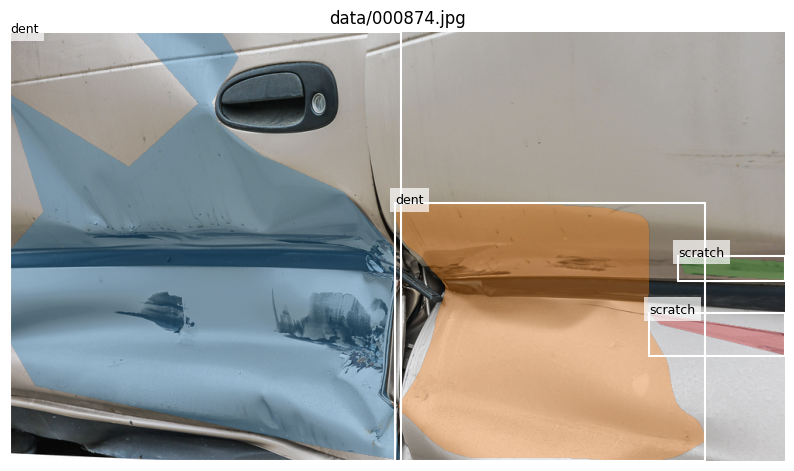

In [30]:
import random

anns_by_img = defaultdict(list)
for a in coco['annotations']:
    anns_by_img[a['image_id']].append(a)

img_rec = random.choice(coco['images'])
img_path = Path(meta_out['snapshot_root']) / img_rec['file_name']
image = np.asarray(Image.open(img_path).convert('RGB'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image)
ax.set_title(img_rec['file_name'])

cat_map = {c['id']: c['name'] for c in coco['categories']}
cmap = plt.cm.get_cmap('tab10')

for i, ann in enumerate(anns_by_img[img_rec['id']][:15]):
    x, y, w, h = ann['bbox']
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, linewidth=1.5, edgecolor='white'))
    ax.text(
        x,
        y,
        cat_map[ann['category_id']],
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

    m = mask_utils.decode(ann['segmentation'])
    m = np.asarray(m)
    if m.ndim == 3:
        m = m[..., 0]

    mask = m.astype(bool)
    if mask.any():
        color = np.array(cmap(i % 10))
        overlay = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=float)
        overlay[mask] = [color[0], color[1], color[2], 0.35]
        ax.imshow(overlay)

ax.axis('off')
plt.show()


#### Analizamos el **balance de clases** a nivel de instancias.

- Contamos cuántas instancias hay por clase.
- Mostramos tabla y gráfico de barras ordenado.

Esto permite detectar clases dominantes o subrepresentadas, un punto clave para interpretar resultados de entrenamiento.


,class,instances
4,scratch,2560
1,dent,1806
0,crack,651
3,lamp broken,494
2,glass shatter,475
5,tire flat,225


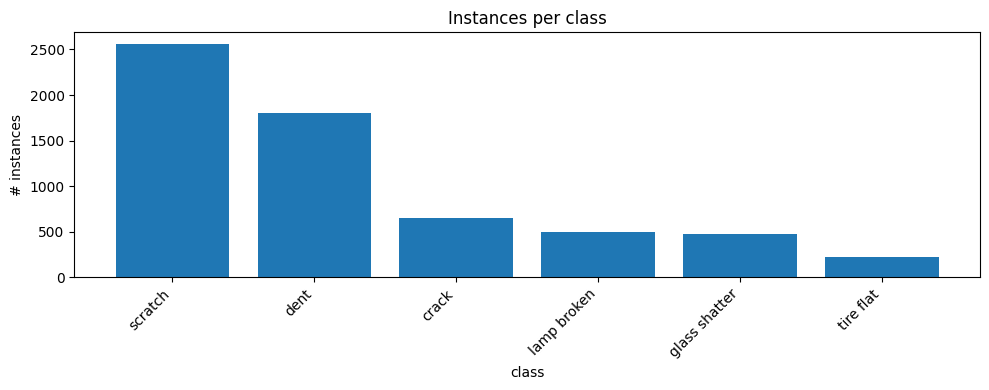

In [13]:
# Distribución de clases
df_cls = pd.DataFrame([
    {'class': c['name'], 'instances': 0} for c in coco['categories']
])

cat_map = {c['id']: c['name'] for c in coco['categories']}
cnt = Counter(cat_map[a['category_id']] for a in coco['annotations'])

for i in range(len(df_cls)):
    cls = df_cls.loc[i, 'class']
    df_cls.loc[i, 'instances'] = cnt.get(cls, 0)

df_cls = df_cls.sort_values('instances', ascending=False)
display(df_cls)

plt.figure(figsize=(10, 4))
plt.bar(df_cls['class'], df_cls['instances'])
plt.title('Instances per class')
plt.xlabel('class')
plt.ylabel('# instances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Estudiamos la **geometría del dataset** y la escala de los objetos anotados.

- Distribución de instancias por imagen.
- Estadísticos de tamaño de imagen (`width`, `height`, `pixels`).
- Distribución de áreas de `bbox` y máscaras.
- Relación `mask_area / bbox_area`.

Este análisis ayuda a entender complejidad visual, densidad de objetos y variabilidad de tamaños.


,width,height,pixels,instances
count,2816.000000,2816.000000,2816.000000,2816.000000
mean,978.997514,705.300781,684298.295455,2.205611
std,77.448657,97.174243,55298.265792,1.551479
min,562.000000,333.000000,333000.000000,1.000000
25%,1000.000000,667.000000,667000.000000,1.000000
50%,1000.000000,667.000000,667000.000000,2.000000
75%,1000.000000,750.000000,673000.000000,3.000000
max,1000.000000,1000.000000,1000000.000000,13.000000


,bbox_area,mask_area
count,6211.000000,6211.000000
mean,116535.319487,78608.516503
std,150864.616151,120630.358062
min,116.616600,60.000000
25%,15547.917000,7584.000000
50%,52758.321000,29108.000000
75%,153433.184950,92049.500000
max,831697.696200,801453.000000


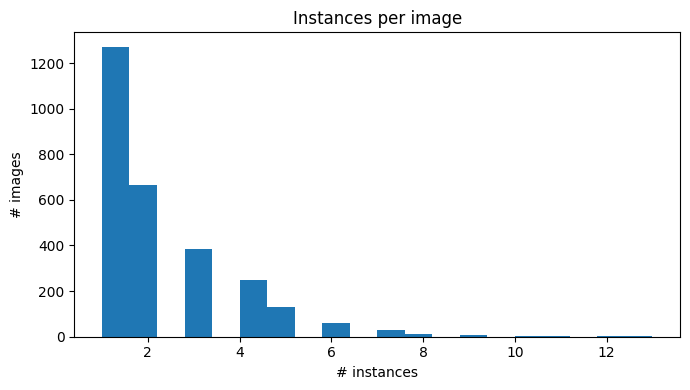

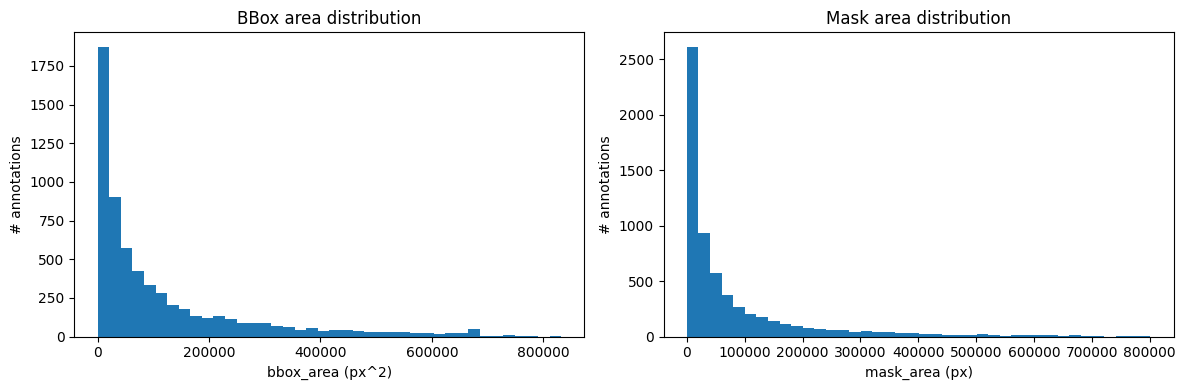

count    6211.000000
mean        0.592249
std         0.200105
min         0.026626
25%         0.474178
50%         0.626099
75%         0.738602
max         1.000000
Name: mask_to_bbox_ratio, dtype: float64

In [14]:
# Geometría: tamaño de imagen, áreas, instancias por imagen
anns_by_img = defaultdict(list)
for a in coco['annotations']:
    anns_by_img[a['image_id']].append(a)

rows_img = []
for im in coco['images']:
    rows_img.append({
        'image_id': im['id'],
        'width': im['width'],
        'height': im['height'],
        'pixels': im['width'] * im['height'],
        'instances': len(anns_by_img[im['id']]),
    })

df_img = pd.DataFrame(rows_img)

df_ann = pd.DataFrame([
    {
        'bbox_w': a['bbox'][2],
        'bbox_h': a['bbox'][3],
        'bbox_area': a['bbox'][2] * a['bbox'][3],
        'mask_area': a.get('area', 0.0),
    }
    for a in coco['annotations']
])

display(df_img[['width', 'height', 'pixels', 'instances']].describe())
display(df_ann[['bbox_area', 'mask_area']].describe())

plt.figure(figsize=(7, 4))
plt.hist(df_img['instances'], bins=20)
plt.title('Instances per image')
plt.xlabel('# instances')
plt.ylabel('# images')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_ann['bbox_area'], bins=40)
axes[0].set_title('BBox area distribution')
axes[0].set_xlabel('bbox_area (px^2)')
axes[0].set_ylabel('# annotations')

axes[1].hist(df_ann['mask_area'], bins=40)
axes[1].set_title('Mask area distribution')
axes[1].set_xlabel('mask_area (px)')
axes[1].set_ylabel('# annotations')

plt.tight_layout()
plt.show()

df_ann['mask_to_bbox_ratio'] = df_ann['mask_area'] / df_ann['bbox_area'].clip(lower=1.0)
display(df_ann['mask_to_bbox_ratio'].describe())


## 6) Escala de daño por clase (small / medium / large)

#### Este análisis mide la **escala de los daños por clase**, usando umbrales tipo COCO sobre `area`:
- `small`: area < 32²
- `medium`: 32² <= area < 96²
- `large`: area >= 96²

Es útil para anticipar dificultad: clases con más instancias pequeñas suelen ser más difíciles de detectar y segmentar.


size_bin,small,medium,large,total
class,,,,
scratch,36,793,1731,2560
dent,31,274,1501,1806
crack,254,339,58,651
lamp broken,0,11,483,494
glass shatter,0,2,473,475
tire flat,0,5,220,225


size_bin,small,medium,large
class,,,
crack,39.02,52.07,8.91
dent,1.72,15.17,83.11
scratch,1.41,30.98,67.62
glass shatter,0.00,0.42,99.58
lamp broken,0.00,2.23,97.77
tire flat,0.00,2.22,97.78


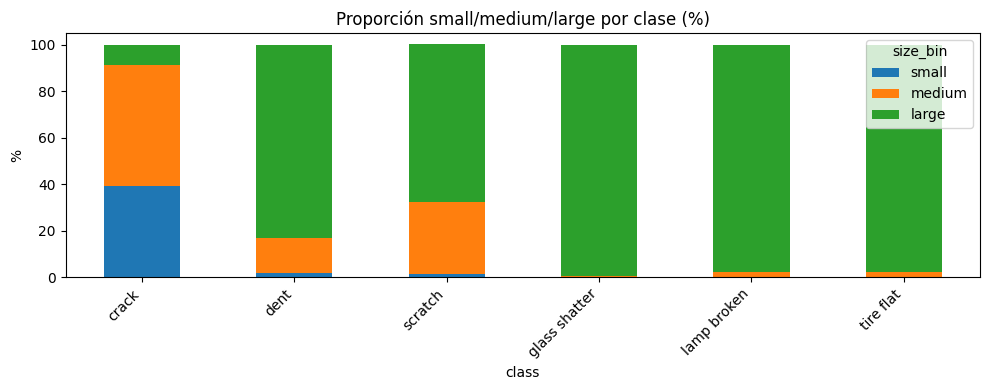

In [16]:
cat_map = {c['id']: c['name'] for c in coco['categories']}

rows_scale = []
for ann in coco['annotations']:
    area = float(ann.get('area', 0.0))
    if area < 32**2:
        size_bin = 'small'
    elif area < 96**2:
        size_bin = 'medium'
    else:
        size_bin = 'large'

    rows_scale.append({
        'class': cat_map[ann['category_id']],
        'area': area,
        'size_bin': size_bin,
    })

df_scale = pd.DataFrame(rows_scale)
scale_table = (
    df_scale
    .pivot_table(index='class', columns='size_bin', values='area', aggfunc='count', fill_value=0)
    .reindex(columns=['small', 'medium', 'large'], fill_value=0)
)
scale_table['total'] = scale_table.sum(axis=1)
scale_pct = (scale_table[['small', 'medium', 'large']].div(scale_table['total'], axis=0) * 100).round(2)

display(scale_table.sort_values('total', ascending=False))
display(scale_pct.sort_values('small', ascending=False))

ax = scale_pct.sort_values('small', ascending=False).plot(kind='bar', stacked=True, figsize=(10, 4))
ax.set_title('Proporción small/medium/large por clase (%)')
ax.set_xlabel('class')
ax.set_ylabel('%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7) Distribución de tamaño por clase

#### Comparamos el rango de tamaños de objetos entre clases:
- `bbox_area`
- `mask_area`

Esto ayuda a detectar clases con alta variabilidad de escala o con colas largas de objetos muy pequeños/grandes.


bbox_area                                           \
                  count           mean            std        min   
class                                                              
crack             651.0   22098.570625   52255.628373   116.6166   
dent             1806.0   92695.052072  102518.181510   135.0594   
glass shatter     475.0  432505.987598  188281.781613  9901.7572   
lamp broken       494.0  165153.398568  136244.355747  1887.5208   
scratch          2560.0   77344.996419  102456.111137   664.1460   
tire flat         225.0  253236.097708  137234.847650  6248.9880   

                                                                       \
                        25%           50%            75%          max   
class                                                                   
crack            2417.12260    6516.60150   18770.507100  518510.8043   
dent            21804.91465   56220.74870  124575.885400  750000.0000   
glass shatter  289062.68250  443770.00000  590674.574500  831697.6962   
lamp broken     61573.46005  124363.25720  237886.389825  743130.0000   
scratch         12995.34215   37337.09705  100855.377000  741270.9742   
tire flat      143885.67600  245741.31600  340951.867300  829700.0000   

              mask_area                                                   \
                  count           mean            std     min        25%   
class                                                                      
crack             651.0    4104.142857    9299.598640    60.0     611.00   
dent             1806.0   59060.301772   67321.430532    89.0   14253.75   
glass shatter     475.0  356860.522105  178569.751124  7991.0  225287.00   
lamp broken       494.0  117704.246964  103675.591964  1352.0   43432.25   
scratch          2560.0   41341.126953   61634.868550   299.0    6663.75   
tire flat         225.0  201843.835556  119269.398317  5174.0  107467.00   

                                              
                    50%        75%       max  
class                                         
crack            1425.0    3685.50  122369.0  
dent            35208.0   78346.00  523422.0  
glass shatter  349062.0  499430.50  780000.0  
lamp broken     87875.0  164530.75  665290.0  
scratch         19168.5   49515.25  622720.0  
tire flat      190795.0  276542.00  801453.0

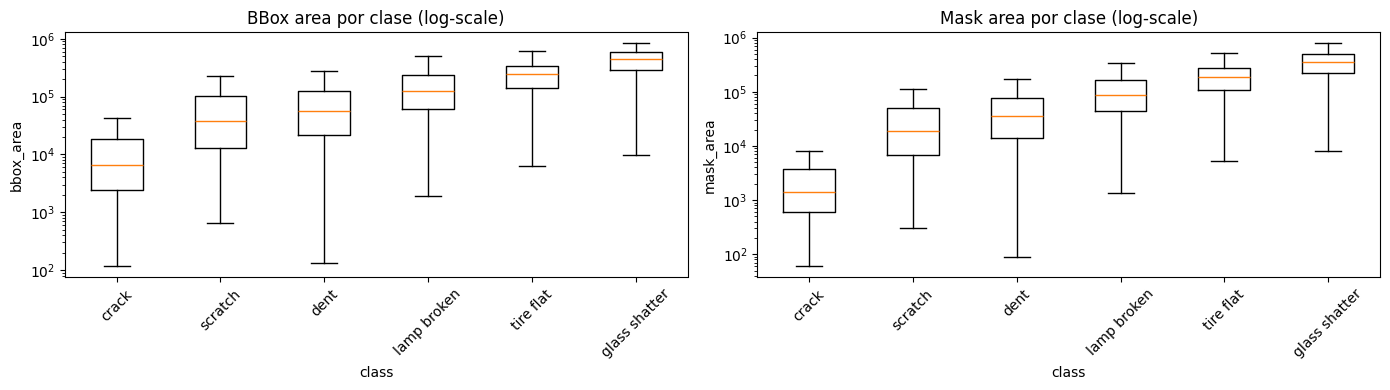

In [17]:
rows_by_class = []
for ann in coco['annotations']:
    x, y, w, h = ann['bbox']
    rows_by_class.append({
        'class': cat_map[ann['category_id']],
        'bbox_area': float(w) * float(h),
        'mask_area': float(ann.get('area', 0.0)),
    })

df_size_cls = pd.DataFrame(rows_by_class)

display(df_size_cls.groupby('class')[['bbox_area', 'mask_area']].describe())

classes_sorted = df_size_cls.groupby('class')['mask_area'].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data_bbox = [df_size_cls[df_size_cls['class'] == c]['bbox_area'].values for c in classes_sorted]
axes[0].boxplot(data_bbox, tick_labels=classes_sorted, showfliers=False)
axes[0].set_yscale('log')
axes[0].set_title('BBox area por clase (log-scale)')
axes[0].set_xlabel('class')
axes[0].set_ylabel('bbox_area')
axes[0].tick_params(axis='x', rotation=45)

data_mask = [df_size_cls[df_size_cls['class'] == c]['mask_area'].values for c in classes_sorted]
axes[1].boxplot(data_mask, tick_labels=classes_sorted, showfliers=False)
axes[1].set_yscale('log')
axes[1].set_title('Mask area por clase (log-scale)')
axes[1].set_xlabel('class')
axes[1].set_ylabel('mask_area')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 8) Heatmap de ubicación del daño (coordenadas normalizadas)

#### Visualizamos dónde aparecen más daños dentro de la imagen, en coordenadas normalizadas `[0,1]`.

Si hay concentración fuerte en ciertas zonas (por ejemplo parte baja o bordes), eso sugiere sesgo de captura o sesgo de anotación.


Instancias consideradas: 6211
cx -> min=0.011, p10=0.249, p50=0.500, p90=0.759, max=0.988
cy -> min=0.022, p10=0.271, p50=0.517, p90=0.785, max=0.982


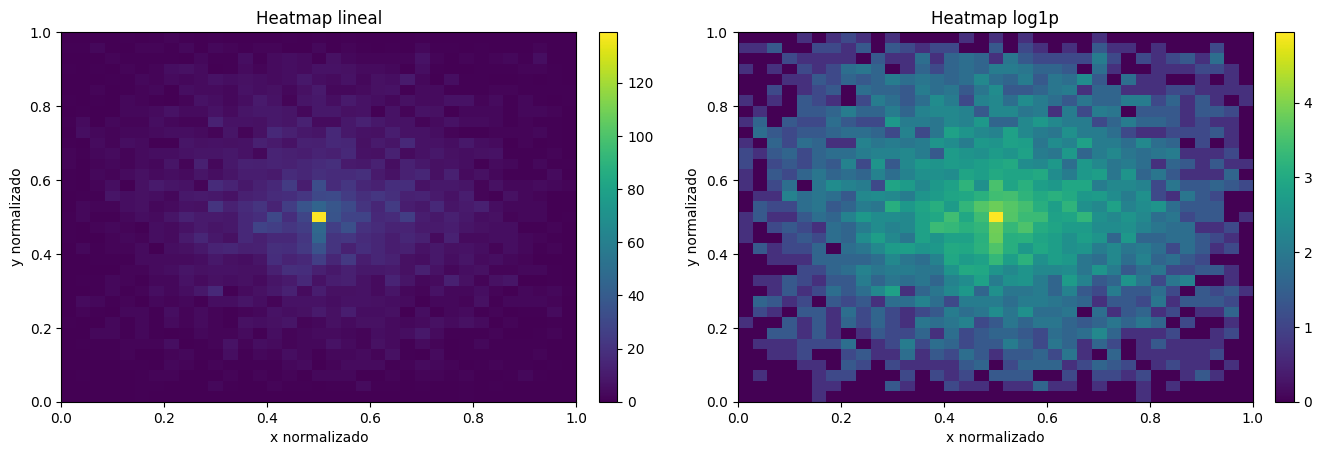

In [29]:
# Mapa de calor usando centro de bbox normalizado
img_by_id = {im['id']: im for im in coco['images']}
xs, ys = [], []

for ann in coco['annotations']:
    im = img_by_id[ann['image_id']]
    iw, ih = float(im['width']), float(im['height'])
    x, y, w, h = ann['bbox']
    cx = (x + w / 2.0) / max(1.0, iw)
    cy = (y + h / 2.0) / max(1.0, ih)

    if 0 <= cx <= 1 and 0 <= cy <= 1:
        xs.append(cx)
        ys.append(cy)

print(f'Instancias consideradas: {len(xs)}')
print(f'cx -> min={min(xs):.3f}, p10={np.quantile(xs,0.10):.3f}, p50={np.quantile(xs,0.50):.3f}, p90={np.quantile(xs,0.90):.3f}, max={max(xs):.3f}')
print(f'cy -> min={min(ys):.3f}, p10={np.quantile(ys,0.10):.3f}, p50={np.quantile(ys,0.50):.3f}, p90={np.quantile(ys,0.90):.3f}, max={max(ys):.3f}')

H, _, _ = np.histogram2d(xs, ys, bins=35, range=[[0, 1], [0, 1]])

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# 1) Heatmap lineal (puede verse muy centrado si el pico central domina)
im0 = axes[0].imshow(H.T, origin='lower', extent=[0, 1, 0, 1], aspect='auto')
axes[0].set_title('Heatmap lineal')
axes[0].set_xlabel('x normalizado')
axes[0].set_ylabel('y normalizado')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# 2) Heatmap log (hace visibles regiones de baja densidad)
Hlog = np.log1p(H)
im1 = axes[1].imshow(Hlog.T, origin='lower', extent=[0, 1, 0, 1], aspect='auto')
axes[1].set_title('Heatmap log1p')
axes[1].set_xlabel('x normalizado')
axes[1].set_ylabel('y normalizado')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)




### Complemento: proximidad del daño al borde

El heatmap de centros puede ocultar daños que tocan bordes si sus centros quedan más adentro.
Esta celda mide explícitamente la **distancia mínima del bbox a los bordes de la imagen** (normalizada)
para verificar cuántas instancias están realmente cerca del borde.


Resumen distancia mínima al borde (normalizada):


count    6211.000000
mean        0.125737
std         0.123252
min         0.000000
25%         0.000000
50%         0.100750
75%         0.213724
max         0.483058
Name: min_dist_norm, dtype: float64

,umbral_dist_norm,pct_instancias_con_min_dist_<umbral
0,0.00,0.000000
1,0.01,30.784093
2,0.02,32.909354
3,0.05,38.979230
4,0.10,49.766543


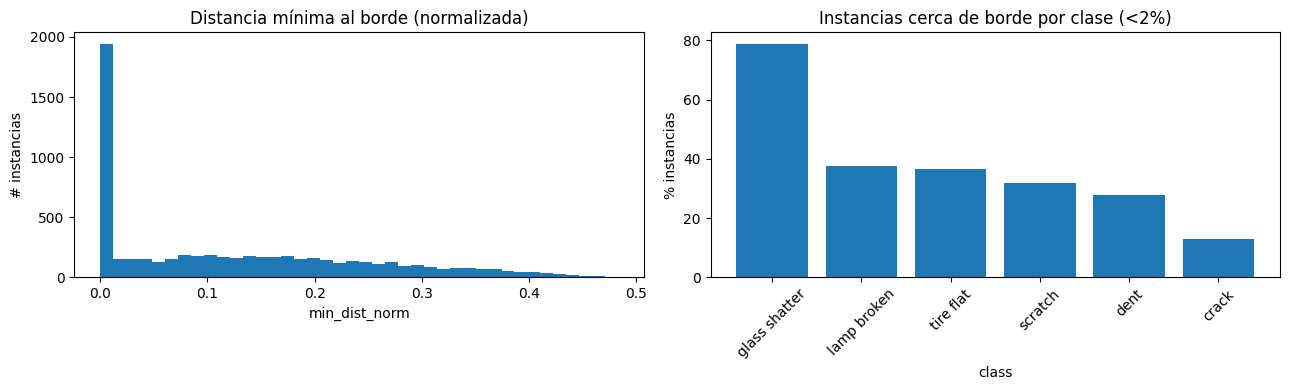

In [27]:
# Distancia mínima del bbox a los bordes (normalizada por tamaño de imagen)
rows_edge = []
for ann in coco['annotations']:
    im = img_by_id[ann['image_id']]
    iw, ih = float(im['width']), float(im['height'])
    x, y, w, h = [float(v) for v in ann['bbox']]

    left = max(0.0, x)
    top = max(0.0, y)
    right = max(0.0, iw - (x + w))
    bottom = max(0.0, ih - (y + h))

    min_dist_px = min(left, top, right, bottom)
    min_dim = max(1.0, min(iw, ih))
    min_dist_norm = min_dist_px / min_dim

    rows_edge.append({
        'class': cat_map[ann['category_id']],
        'min_dist_px': min_dist_px,
        'min_dist_norm': min_dist_norm,
    })

df_edge = pd.DataFrame(rows_edge)

print('Resumen distancia mínima al borde (normalizada):')
display(df_edge['min_dist_norm'].describe())

thresholds = [0.00, 0.01, 0.02, 0.05, 0.10]
summary = []
for t in thresholds:
    summary.append({
        'umbral_dist_norm': t,
        'pct_instancias_con_min_dist_<umbral': float((df_edge['min_dist_norm'] < t).mean() * 100),
    })

df_edge_summary = pd.DataFrame(summary)
display(df_edge_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_edge['min_dist_norm'], bins=40)
axes[0].set_title('Distancia mínima al borde (normalizada)')
axes[0].set_xlabel('min_dist_norm')
axes[0].set_ylabel('# instancias')

near_border_rate = (df_edge.assign(near_border=df_edge['min_dist_norm'] < 0.02)
                    .groupby('class')['near_border']
                    .mean()
                    .sort_values(ascending=False) * 100)

axes[1].bar(near_border_rate.index, near_border_rate.values)
axes[1].set_title('Instancias cerca de borde por clase (<2%)')
axes[1].set_xlabel('class')
axes[1].set_ylabel('% instancias')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 9) Severidad del daño (proxies geométricos)

Como proxy de severidad usamos:
- `mask_area / image_area` (impacto relativo en la imagen)
- `mask_area / bbox_area` (ocupación de la máscara dentro del bbox)

No reemplaza una etiqueta clínica de severidad, pero sirve para comparar clases en términos relativos.


mask_over_image                                          \
                        count      mean       std       min       25%   
class                                                                   
crack                   651.0  0.005960  0.013638  0.000090  0.000900   
dent                   1806.0  0.086662  0.098389  0.000133  0.020462   
glass shatter           475.0  0.528898  0.261677  0.011981  0.339885   
lamp broken             494.0  0.171323  0.149724  0.001800  0.064117   
scratch                2560.0  0.059989  0.088309  0.000447  0.009696   
tire flat               225.0  0.296086  0.167155  0.007757  0.160475   

                                            mask_over_bbox            \
                    50%       75%       max          count      mean   
class                                                                  
crack          0.002122  0.005348  0.183462          651.0  0.287521   
dent           0.051171  0.117370  0.784741         1806.0  0.649631   
glass shatter  0.519027  0.733832  1.000000          475.0  0.805367   
lamp broken    0.126109  0.244382  0.997436          494.0  0.713168   
scratch        0.027979  0.072326  0.913966         2560.0  0.549999   
tire flat      0.285085  0.413985  0.945110          225.0  0.778653   

                                                                           
                    std       min       25%       50%       75%       max  
class                                                                      
crack          0.177783  0.026626  0.136071  0.257507  0.394069  0.943749  
dent           0.123256  0.187785  0.573033  0.668034  0.742407  0.928978  
glass shatter  0.121035  0.381357  0.716873  0.827087  0.898169  1.000000  
lamp broken    0.122236  0.401131  0.622504  0.714181  0.814937  0.997436  
scratch        0.173606  0.039965  0.429695  0.567290  0.684006  0.972388  
tire flat      0.086476  0.425647  0.759034  0.802334  0.826075  0.965955

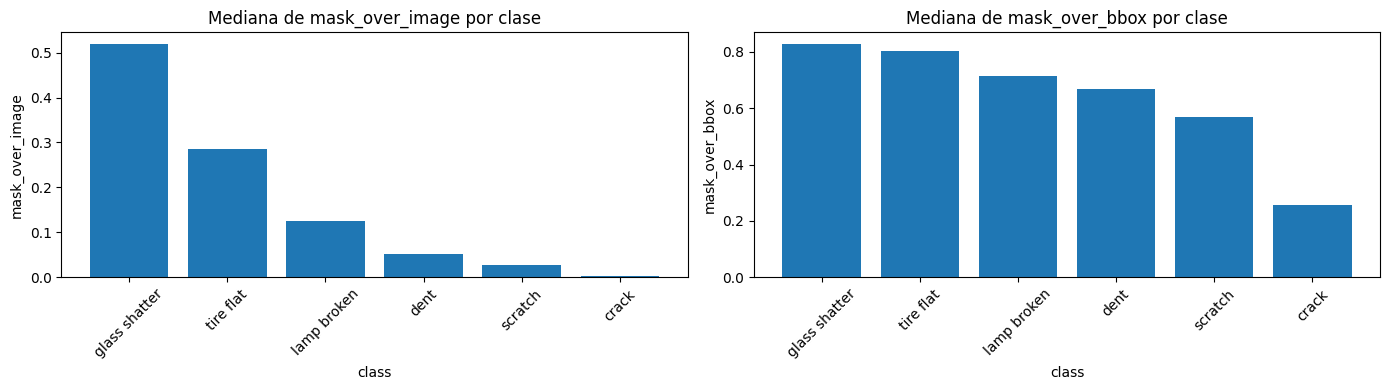

In [19]:
rows_severity = []
for ann in coco['annotations']:
    im = img_by_id[ann['image_id']]
    img_area = float(im['width']) * float(im['height'])
    x, y, w, h = ann['bbox']
    bbox_area = max(float(w) * float(h), 1.0)
    mask_area = float(ann.get('area', 0.0))

    rows_severity.append({
        'class': cat_map[ann['category_id']],
        'mask_over_image': mask_area / max(img_area, 1.0),
        'mask_over_bbox': mask_area / bbox_area,
    })

df_sev = pd.DataFrame(rows_severity)
display(df_sev.groupby('class')[['mask_over_image', 'mask_over_bbox']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for metric, ax in [('mask_over_image', axes[0]), ('mask_over_bbox', axes[1])]:
    med = df_sev.groupby('class')[metric].median().sort_values(ascending=False)
    ax.bar(med.index, med.values)
    ax.set_title(f'Mediana de {metric} por clase')
    ax.set_xlabel('class')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 10) Co-ocurrencia de clases y multi-daño por imagen

Analizamos complejidad de escena en dos frentes:
- cuántas instancias hay por imagen
- qué clases tienden a aparecer juntas (co-ocurrencia)

Esto ayuda a entender escenarios multi-daño y potenciales confusiones entre clases.


count    2816.000000
mean        2.205611
std         1.551479
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        13.000000
Name: instances_per_image, dtype: float64

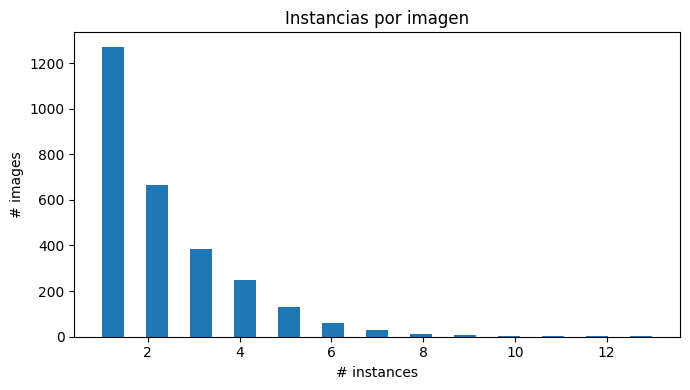

,crack,dent,glass shatter,lamp broken,scratch,tire flat
crack,434,250,11,162,262,16
dent,250,1242,66,320,648,29
glass shatter,11,66,469,10,16,0
lamp broken,162,320,10,489,268,10
scratch,262,648,16,268,1507,34
tire flat,16,29,0,10,34,219


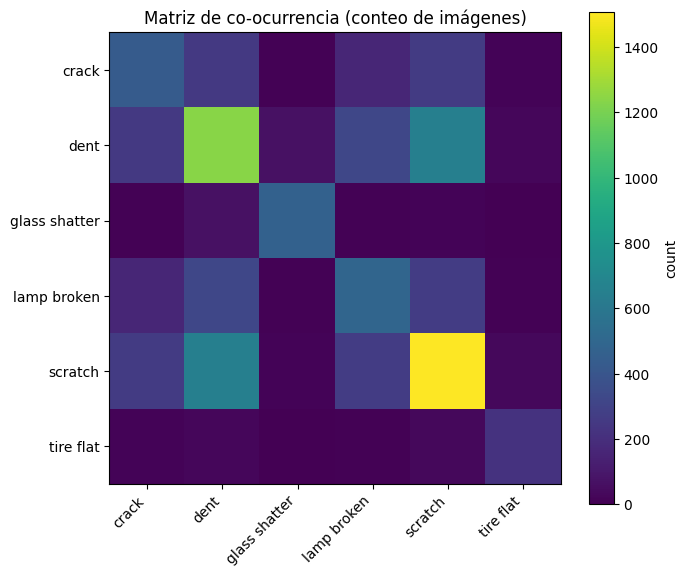

In [20]:
# Instancias por imagen
inst_per_image = pd.Series([len(anns_by_img[im['id']]) for im in coco['images']], name='instances_per_image')
display(inst_per_image.describe())

plt.figure(figsize=(7, 4))
plt.hist(inst_per_image, bins=25)
plt.title('Instancias por imagen')
plt.xlabel('# instances')
plt.ylabel('# images')
plt.tight_layout()
plt.show()

# Matriz de co-ocurrencia por presencia de clase en imagen
classes = [c['name'] for c in coco['categories']]
img_classes = []
for im in coco['images']:
    cls_set = set(cat_map[a['category_id']] for a in anns_by_img[im['id']])
    img_classes.append(cls_set)

co_mat = pd.DataFrame(0, index=classes, columns=classes, dtype=int)
for cls_set in img_classes:
    for c1 in cls_set:
        for c2 in cls_set:
            co_mat.loc[c1, c2] += 1

display(co_mat)

plt.figure(figsize=(7, 6))
plt.imshow(co_mat.values)
plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
plt.yticks(range(len(classes)), classes)
plt.title('Matriz de co-ocurrencia (conteo de imágenes)')
plt.colorbar(label='count')
plt.tight_layout()
plt.show()


## 11) Chequeos de calidad de anotación (outliers)

Buscamos anomalías que puedan afectar entrenamiento y evaluación:
- áreas no positivas
- bbox fuera de límites de imagen
- `mask_area` mayor que `bbox_area` por margen amplio

Esto funciona como control de calidad previo a modelado.


In [21]:
rows_qc = []
for ann in coco['annotations']:
    im = img_by_id[ann['image_id']]
    iw, ih = float(im['width']), float(im['height'])
    x, y, w, h = [float(v) for v in ann['bbox']]
    bbox_area = w * h
    mask_area = float(ann.get('area', 0.0))

    rows_qc.append({
        'class': cat_map[ann['category_id']],
        'bbox_area_non_positive': bbox_area <= 0,
        'mask_area_non_positive': mask_area <= 0,
        'bbox_outside_image': (x < 0) or (y < 0) or (x + w > iw + 1e-6) or (y + h > ih + 1e-6),
        'mask_gt_bbox_120pct': mask_area > (bbox_area * 1.2 if bbox_area > 0 else 0),
    })

df_qc = pd.DataFrame(rows_qc)
qc_summary = pd.DataFrame({
    'count_true': df_qc[['bbox_area_non_positive', 'mask_area_non_positive', 'bbox_outside_image', 'mask_gt_bbox_120pct']].sum(),
    'pct_true': (df_qc[['bbox_area_non_positive', 'mask_area_non_positive', 'bbox_outside_image', 'mask_gt_bbox_120pct']].mean() * 100).round(4),
})

display(qc_summary)

# Ver por clase para priorizar limpieza
qc_by_class = df_qc.groupby('class')[['bbox_area_non_positive', 'mask_area_non_positive', 'bbox_outside_image', 'mask_gt_bbox_120pct']].mean() * 100
display(qc_by_class.round(4))


,count_true,pct_true
bbox_area_non_positive,0,0.0
mask_area_non_positive,0,0.0
bbox_outside_image,0,0.0
mask_gt_bbox_120pct,0,0.0


,bbox_area_non_positive,mask_area_non_positive,bbox_outside_image,mask_gt_bbox_120pct
class,,,,
crack,0.0,0.0,0.0,0.0
dent,0.0,0.0,0.0,0.0
glass shatter,0.0,0.0,0.0,0.0
lamp broken,0.0,0.0,0.0,0.0
scratch,0.0,0.0,0.0,0.0
tire flat,0.0,0.0,0.0,0.0


## 12) Sensibilidad a resolución (simulación de downsampling)

CarDD tiene imágenes de alta resolución. Este análisis estima cuánto se degradaría el dataset
si se reduce resolución, observando la proporción de objetos que quedarían por debajo de umbral de área.

Se calcula una aproximación escalando `mask_area` por `factor²`.


,scale_factor,area_threshold,pct_instances_below_threshold
0,1.00,16,0.000000
1,1.00,32,0.000000
2,1.00,64,0.016100
3,1.00,128,0.193206
4,0.75,16,0.000000
5,0.75,32,0.000000
6,0.75,64,0.161005
7,0.75,128,0.788923
8,0.50,16,0.016100
9,0.50,32,0.193206


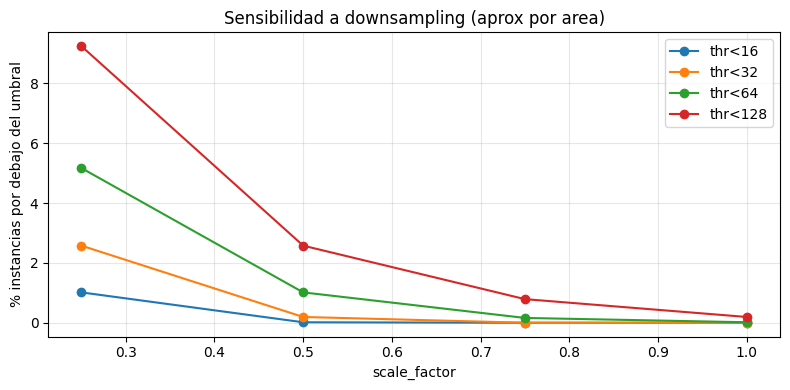

In [22]:
scale_factors = [1.0, 0.75, 0.5, 0.25]
area_thresholds = [16, 32, 64, 128]  # píxeles de área mínima

base_mask_area = np.array([float(a.get('area', 0.0)) for a in coco['annotations']], dtype=float)

rows_res = []
for sf in scale_factors:
    scaled_area = base_mask_area * (sf ** 2)
    for thr in area_thresholds:
        pct_below = float((scaled_area < thr).mean() * 100)
        rows_res.append({
            'scale_factor': sf,
            'area_threshold': thr,
            'pct_instances_below_threshold': pct_below,
        })

df_res = pd.DataFrame(rows_res)
display(df_res)

fig, ax = plt.subplots(figsize=(8, 4))
for thr in area_thresholds:
    d = df_res[df_res['area_threshold'] == thr]
    ax.plot(d['scale_factor'], d['pct_instances_below_threshold'], marker='o', label=f'thr<{thr}')

ax.set_title('Sensibilidad a downsampling (aprox por area)')
ax.set_xlabel('scale_factor')
ax.set_ylabel('% instancias por debajo del umbral')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 13) Índice simple de dificultad por clase

Construimos un índice descriptivo (no oficial) combinando:
- porcentaje de objetos `small`
- mediana de `mask_over_image` (a menor valor, mayor dificultad)
- densidad media de instancias por imagen donde aparece la clase

Sirve para priorizar clases en estrategias de entrenamiento/augmentación.


,small_rate_pct,median_mask_over_image,mean_instances_when_present,difficulty_score
crack,39.016897,0.002122,1.500000,0.942270
scratch,1.406250,0.027979,1.698739,0.503014
dent,1.716501,0.051171,1.454106,0.422468
lamp broken,0.000000,0.126109,1.010225,0.228040
tire flat,0.000000,0.285085,1.027397,0.140763
glass shatter,0.000000,0.519027,1.012793,0.000746


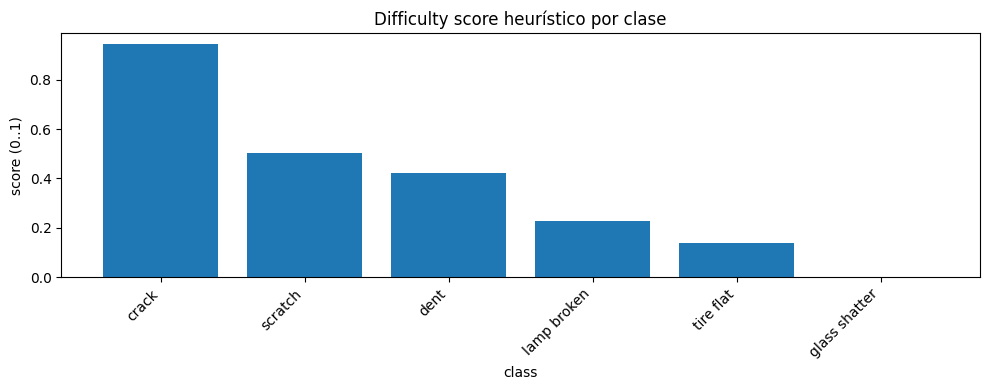

In [23]:
# small rate por clase
small_rate = (df_scale.assign(is_small=df_scale['size_bin'] == 'small')
              .groupby('class')['is_small'].mean() * 100)

# mediana de severidad relativa por clase
sev_median = df_sev.groupby('class')['mask_over_image'].median()

# densidad de instancias por imagen donde aparece cada clase
class_img_counts = defaultdict(list)
for im in coco['images']:
    anns = anns_by_img[im['id']]
    if not anns:
        continue
    per_class_count = Counter(cat_map[a['category_id']] for a in anns)
    for cls, n in per_class_count.items():
        class_img_counts[cls].append(n)

density = pd.Series({cls: float(np.mean(v)) for cls, v in class_img_counts.items()})

classes_all = sorted(set(list(small_rate.index) + list(sev_median.index) + list(density.index)))
df_diff = pd.DataFrame(index=classes_all)
df_diff['small_rate_pct'] = small_rate.reindex(classes_all)
df_diff['median_mask_over_image'] = sev_median.reindex(classes_all)
df_diff['mean_instances_when_present'] = density.reindex(classes_all)

# Score heurístico: más small + menor área relativa + mayor densidad -> más difícil
# Normalizamos a [0,1]
def norm01(s):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx <= mn:
        return pd.Series(0.0, index=s.index)
    return (s - mn) / (mx - mn)

small_n = norm01(df_diff['small_rate_pct'].fillna(0))
inv_area_n = 1.0 - norm01(df_diff['median_mask_over_image'].fillna(0))
dens_n = norm01(df_diff['mean_instances_when_present'].fillna(0))

df_diff['difficulty_score'] = (0.5 * small_n + 0.3 * inv_area_n + 0.2 * dens_n)
df_diff = df_diff.sort_values('difficulty_score', ascending=False)

display(df_diff)

plt.figure(figsize=(10, 4))
plt.bar(df_diff.index, df_diff['difficulty_score'])
plt.title('Difficulty score heurístico por clase')
plt.xlabel('class')
plt.ylabel('score (0..1)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Conclusión breve del EDA

A partir de las salidas obtenidas, el dataset reconstruido en COCO muestra buena consistencia estructural y un perfil de dificultad claro para segmentación de daños:

- Se analizaron **2816 imágenes** y **6211 instancias** (promedio: **2.21 instancias/imagen**), con **6 clases**.
- La integridad de anotaciones es alta: no se observaron desalineaciones entre `detections` y `segmentations`, ni outliers geométricos básicos (`bbox` fuera de imagen, áreas no positivas, etc.).
- Existe **desbalance de clases**: `scratch` y `dent` concentran la mayor cantidad de instancias, mientras que `tire flat` es minoritaria.
- En escala de objeto, predominan daños grandes en varias clases; sin embargo, `crack` presenta una proporción alta de instancias pequeñas, lo que la vuelve una clase potencialmente más desafiante.
- La cobertura de máscara respecto del bbox (`mask_to_bbox_ratio`) tiene mediana aproximada de **0.63**, indicando que muchas anotaciones ocupan una parte relevante del cuadro detectado.
- En ubicación espacial, los centros de bbox muestran mayor densidad en zona central, pero el análisis de proximidad a bordes confirma que una fracción importante de instancias está cerca de los límites de imagen (por ejemplo, ~**33%** dentro del 2% del borde).

En conjunto, CarDD reconstruido se ve **apto para entrenamiento y evaluación**, aunque el desbalance entre clases y la presencia de daños pequeños (especialmente en `crack`) sugieren considerar estrategias de balanceo/augmentación durante el modelado.
